# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the slope coefficient in a linear regression?
8. Compare the train/test split and $k$-fold cross validation.
9. How is the $k$ in $k$-fold cross validation typically selected?

1 - Linear refers to how the model combines its inputs, specifically linear in the parameters - it means youre adding up the weighted versions of your features, and the weighted coefficents and output is always a straight line sum. The features themselves can be curved, but the weights always enter additivley, never multiplied together or raised to a power.

2 - When you have a catagory coded as 0/1 (ex male female), one catagory gets dropped, getting absorbed into the reference group, absorbed into the intercept. the coefficent on the remaining dummy tells you the difference from that baseline. Ex if the intercept is 50 and the coefficent for 'female' is 8, the model says males average 50, females average 58, you interpret dummy coefficents relative to the dropped group. 

3 - technically it can be run, but ends up being a poor fit. the issue is that linear regression predicts a continuous number that can go below 0 or above 1 which is meaningless for a probability. it also assumes the errors are normally distributed and constant, both wrong for binary outcomes. logistic regression would be the right tool tho, it constrains predictions to [0,1] and uses a probability model suited to catagorical outcomes. 

4 - overfitting is when the model memorizes the training data instead of learning the true patterns. Giveaways that this is happening include the training error being extremely low, but the test error is much higher, model performance doing much worse on new data, coefficents being unreasonably large, and the model has too many features relative to observations

5 - multicollinearity means two or more of your predictors move toegtehr, so you can't exactly tell which one is causing the outcome. the classic fix is two stage least squares (2SLS) - find an instrument (a variable that predicts the problematic predictor but doesnt directly affect the outcome) - for stage 1, regress the problematic predictor on the instrument then get the predicted values (the clean variation) - for stage 2, use those predicted values in place of the original predictor in your main regression - this isolates the only variation in your predictor thats uncontaminated by the collinearity problem

6 - while staying in the linear regression framework, there are several options - 
* Polynomial terms - add x^2, x^3 as extra features. The model is still linear in coefficients
* Log transforms - take log(x) or log(y) to linearize exponential/skewed relationships
* Interaction terms -  multiply two features together (x1 × x2) to let the effect of one depend on the other
* Splines -  fit piecewise polynomials with smooth joins at "knot" points
* Binning -  convert a continuous variable into categories

7 - the slope coefficent on variable x means holding everything else constant, a one unit increase in x is associated with a Beta unit change in y, ex if B = 3.5, then every additional unit of x predicts 3.5 more units of y on average, with other predictors fixed (associated with, not causes)

8 - both these exsist to help estimate how well your model generalizes 
* for train/test split, you chop up the data once into a train and test section, train on the bigger half generally, and evaluate on the other. its simple but can be noisy, your estimate of model quality depends heavily on which rows happened to land in the test set
* for k-fold CV, you split k into equal chunks, and the model trains k times, each time using a different chunk as the test set and the rest as training. you then get average k error scores. this uses your data more efficently and gives a more stable estimate of performance, at the cost of k x the compute 

9 - the most common default is k=5 or k=10, these have been shown to empirically balance bias and variance in the error estimate as well. the other case k=n (leave one out CV) uses every point as its own test set, with very low bias, but computationally expensive and high variance. larger k means less bias and more variance in the estimate, more compute - smaller k means faster but noisier


**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

                Price  Review Scores Rating
Neighbourhood                              
Manhattan      183.66                 91.80
Staten Island  146.17                 90.84
Brooklyn       127.75                 92.36
Queens          96.86                 91.55
Bronx           75.28                 91.65

Most expensive borough on average-  Manhattan


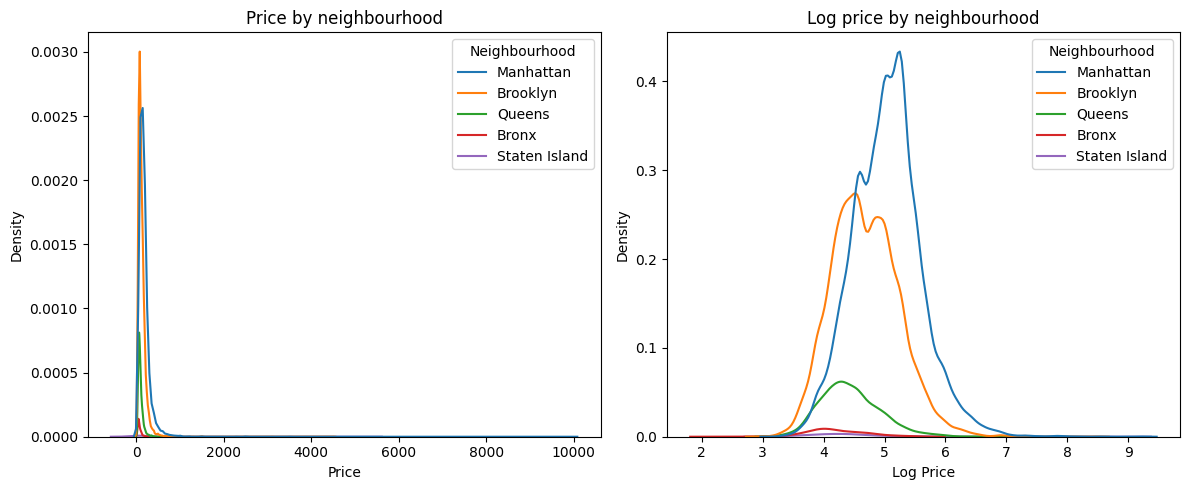

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Sat, 21 Mar 2026   Prob (F-statistic):          4.43e-226
Time:                        19:57:06   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:                         2.835e+05
Df Residuals:                   22148   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            75.2765      9.868      7.628

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# 1 
df = pd.read_csv("Q1_clean.csv")
df = df.rename(columns={'Neighbourhood ': 'Neighbourhood'})
df['Log Price'] = np.log(df['Price'])
summary = (
    df.groupby('Neighbourhood')[['Price', 'Review Scores Rating']]
    .mean()
    .round(2)
    .sort_values('Price', ascending=False)
)
print(summary.to_string())
print(f"\nMost expensive borough on average-  {summary['Price'].idxmax()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.kdeplot(data=df, x='Price',     hue='Neighbourhood', ax=axes[0])
sns.kdeplot(data=df, x='Log Price', hue='Neighbourhood', ax=axes[1])

axes[0].set_title('Price by neighbourhood')
axes[1].set_title('Log price by neighbourhood')

plt.tight_layout()
plt.show()

# 2
# Regress price on neighbourhood dummies (drop first category then keep intercept)
# Dropped category is the reference group, its mean = intercept

X = pd.get_dummies(df['Neighbourhood'], drop_first=True, dtype=int)
X = sm.add_constant(X)
model = sm.OLS(df['Price'], X).fit()
print(model.summary())
# in this, we drop one borough (alphabetically first) and keep the intercept
# the intercept is the mean of the price dropped (refernece borrough)
# each coefficent is the difference in mean price between that borough and the reference borough
# so intercept+ coefficent for an borough is that boroughs conditional mean from part 1, they are exactly the
# same numbers, just expressed as deviations from the baseline rather than raw means
# specifically, The intercept (75.28) = the Bronx's mean price from part 1 — identical.
# Each coefficient = that boroughs mean minus the bronx's mean. 
# ex Manhattans coefficient is 108.39, and 75.28 + 108.39 = 183.67 — manhattans mean price 
# from part 1 (rounding aside)

# 3 
X = sm.add_constant(df['Review Scores Rating'])
model2 = sm.OLS(df['Price'], X).fit()
print(model2.summary())
# the slope coefficent for review scores rating is 1.02, whcih means for every one point increase in a property's
# average review score, the nightly price is assoicated with a 1.02 increase on average - also, 
# R squared is only 0.004 meaning review score explains less than 1% of the variation on price (poor predictor of price 
# on its own)

# 4 
neighbourhood_dummies = pd.get_dummies(df['Neighbourhood'], drop_first=True, dtype=int)
X = pd.concat([neighbourhood_dummies, df['Review Scores Rating']], axis=1)
X = sm.add_constant(X)
model3 = sm.OLS(df['Price'], X).fit()
print(model3.summary())
# coefficent now changed to negative and not significant (P=0.091) - R squared only went from 0.046 to 0.05
# by adding review score, so neighborhood does almost all the explanatory work here, review score adds 
# almost nothing on top

# 5 
neighbourhood_dummies = pd.get_dummies(df['Neighbourhood'], drop_first=True, dtype=int)

for col in neighbourhood_dummies.columns:
    neighbourhood_dummies[f'{col} × Rating'] = neighbourhood_dummies[col] * df['Review Scores Rating']

X = pd.concat([neighbourhood_dummies, df['Review Scores Rating']], axis=1)
X = sm.add_constant(X)
model5 = sm.OLS(df['Price'], X).fit()
print(model5.summary())
# the slopes are NOT similar across neighborhoods, brooklyn, manhattan, queens, and the bronx. have slopes near
# 0 and are statistically insignificant, but staten island has a slope of -31.26, super different
# I think this is the puzzle - the overall positive relationship from question 3 largely dissapears
# once you allow slopes to vary by neighborhood

# 6
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

X3 = df[['Review Scores Rating']]

neighbourhood_dummies = pd.get_dummies(df['Neighbourhood'], drop_first=True, dtype=int)
X4 = pd.concat([neighbourhood_dummies, df['Review Scores Rating']], axis=1)

X5 = X4.copy()
for col in neighbourhood_dummies.columns:
    X5[f'{col} × Rating'] = neighbourhood_dummies[col] * df['Review Scores Rating']

y = df['Price']

for name, X in [('Part 3', X3), ('Part 4', X4), ('Part 5', X5)]:
    scores = cross_val_score(LinearRegression(), X, y, cv=5, scoring='neg_root_mean_squared_error')
    print(f"{name} — Mean RMSE: {-scores.mean():.2f}, Std: {scores.std():.2f}")
# (see numerical outputs below)
# shows that all 3 models perform similarly poorly, RMSEs of 142-146$ per night is large relative to avg prices
# part 4 (adding nieghborhood) gives best RMSE, while adding interactoin terms in part 5 makes it slightly worse
# suggests the interactions are overfitting maybe - part 3 weakest overall, overall no model particularly
# useful predictors of price

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`. 
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


Price summary-
count        976.00
mean      741019.47
std       367323.38
min       188000.00
25%       475750.00
50%       666500.00
75%       883000.00
max      2941000.00
Name: Price, dtype: float64

Price by body type-
           count        mean        std       min       25%        50%        75%        max
Body_Type                                                                                   
crossover   21.0   705095.24   72849.78  608000.0  638000.0   706000.0   749000.0   883000.0
hatchback  484.0   533977.27  173086.73  188000.0  401750.0   509000.0   661000.0  1107000.0
muv         38.0   626421.05  184093.49  328000.0  489750.0   621500.0   738500.0  1091000.0
sedan      227.0   809784.14  286736.77  368000.0  598000.0   772000.0   968500.0  2941000.0
suv        206.0  1176495.15  417479.03  559000.0  860000.0  1065000.0  1491250.0  2100000.0


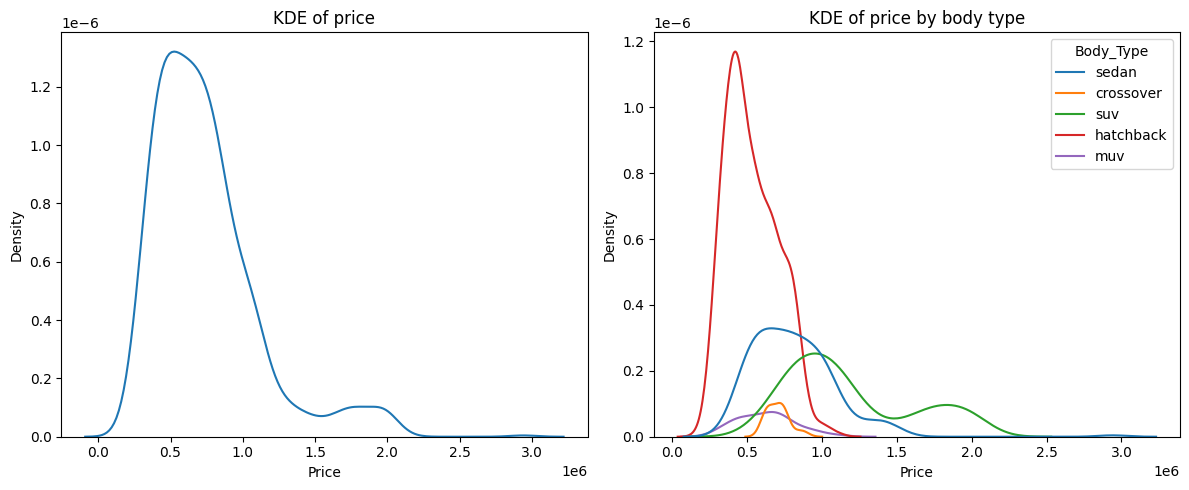

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     5.075
Date:                Sun, 22 Mar 2026   Prob (F-statistic):             0.0245
Time:                        15:31:03   Log-Likelihood:                -13888.
No. Observations:                 976   AIC:                         2.778e+04
Df Residuals:                     974   BIC:                         2.779e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              4.39e+05   1.35e+05  

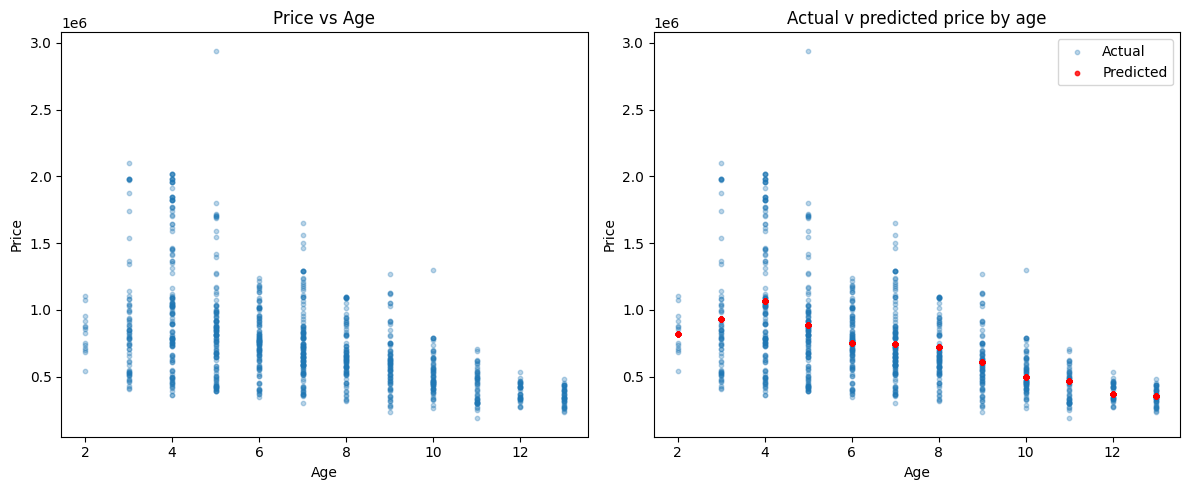

In [28]:
# 1
df = pd.read_csv('data/cars_hw.csv')
print("Price summary-")
print(df['Price'].describe().round(2))
print("\nPrice by body type-")
print(df.groupby('Body_Type')['Price'].describe().round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.kdeplot(data=df, x='Price', ax=axes[0])
sns.kdeplot(data=df, x='Price', hue='Body_Type', ax=axes[1])
axes[0].set_title('KDE of price')
axes[1].set_title('KDE of price by body type')
plt.tight_layout()
plt.show()
# suvs are the most expensive and also have the most variance - sedans have second highest mean and std

# 2
X = sm.add_constant(df['Seating_Capacity'])
model1 = sm.OLS(df['Price'], X).fit()
print(model1.summary())

seat_dummies = pd.get_dummies(df['Seating_Capacity'], drop_first=True, dtype=int)
X_cat = sm.add_constant(seat_dummies)
model2 = sm.OLS(df['Price'], X_cat).fit()
print(model2.summary())
# the slope is 59,270, meaning each additional seat is associated with a 59,270 increase in price on average. 
# however rsquared is only 0.005 — seating capacity alone explains almost nothing
# differences in seats don't seem to be linear, each extra seat doesnt seem to be adding the same amount
# accoridng to the model 
# The jump from 5 to 6 is large then it drops back down at 7 and 8 — 
# thats not linear at all. also note most of these coefficients are statistically insignificant 
# except for 6 seaters, so theress a lot of noise, the continuous models assumption of a smooth linear increase 
# per seat is not supported by the data

# 3
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

df['Age'] = 2024 - df['Make_Year']

results = []
for degree in range(1, 11):
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly.fit_transform(df[['Age']])
    rmse = -cross_val_score(LinearRegression(), X_poly, df['Price'], 
                            cv=10, scoring='neg_root_mean_squared_error').mean()
    results.append({'Degree': degree, 'RMSE': round(rmse, 2)})

results_df = pd.DataFrame(results)
print(results_df)
# optimal degree is 8 with the lowest RMSE of 306482 - however diffs across all degrees are tiny, spread
# of less than 0.6%, suggests age alone is a poor predictor of price regardless of how many polynominal terms you add
# and the winner at degree 8 is likely just noise ratehr than a meaningful improvement

# 4
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=8, include_bias=False)
X_poly = poly.fit_transform(df[['Age']])
model_poly = LinearRegression().fit(X_poly, df['Price'])
df['Predicted_Price'] = model_poly.predict(X_poly)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(df['Age'], df['Price'], alpha=0.3, s=10)
axes[0].set_title('Price vs Age')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Price')
axes[1].scatter(df['Age'], df['Price'], alpha=0.3, s=10, label='Actual')
axes[1].scatter(df['Age'], df['Predicted_Price'], alpha=0.8, s=10, color='red', label='Predicted')
axes[1].set_title('Actual v predicted price by age')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Price')
axes[1].legend()
plt.tight_layout()
plt.show()
# the model shows the general downward trend, that older cars are cheaper, and the predicted values track the
# mean price decently well at each age. however, it fails to clearly captrue the massive vertical spread at 
# every age value (each has a huge range and the model guesses in the middle)- ge alone cant explain why
# 2 4 year old cars may haved such different prices, so other features would assist with that. so the model
# fits the average trend but misses almost all the variation

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1. 
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models. 
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


Control survival rate is   0.1176
Treatment survival rate- 0.3478
ATE-                     0.2302
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     6.354
Date:                Sun, 22 Mar 2026   Prob (F-statistic):             0.0133
Time:                        17:21:58   Log-Likelihood:                -59.591
No. Observations:                 103   AIC:                             123.2
Df Residuals:                     101   BIC:                             128.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------

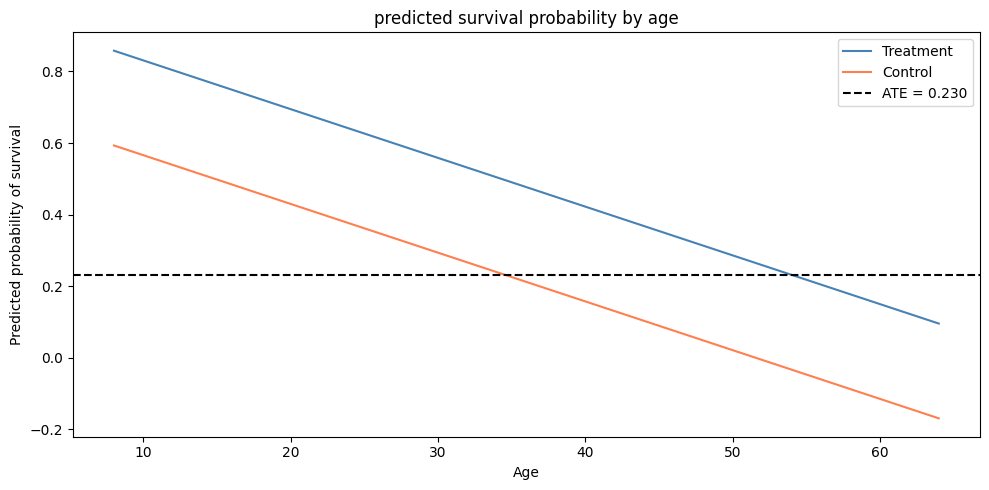

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.172
Model:                            OLS   Adj. R-squared:                  0.147
Method:                 Least Squares   F-statistic:                     6.839
Date:                Sun, 22 Mar 2026   Prob (F-statistic):           0.000310
Time:                        17:21:58   Log-Likelihood:                -53.033
No. Observations:                 103   AIC:                             114.1
Df Residuals:                      99   BIC:                             124.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.3549      0.280     

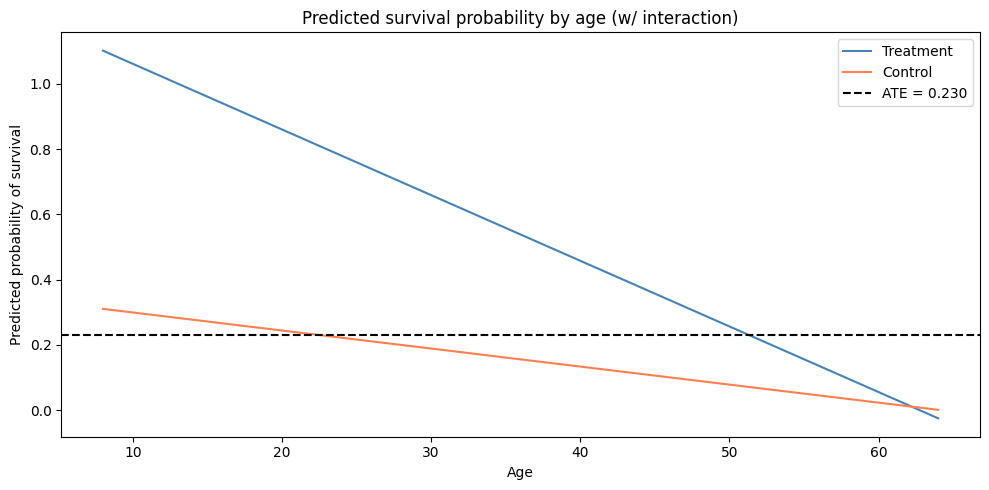

Part 2 (transplant only) — RMSE: 0.4355
Part 3 (transplant + age) — RMSE: 0.4212
Part 4 (+ interaction) — RMSE: 0.4129


In [ ]:
import statsmodels.api as sm

df = pd.read_csv('data/heart_hw.csv')

# 1
proportions = df.groupby('transplant')['y'].mean()
control_rate = proportions['control']
treatment_rate = proportions['treatment']
ATE = treatment_rate - control_rate

print(f"Control survival rate is   {control_rate:.4f}")
print(f"Treatment survival rate- {treatment_rate:.4f}")
print(f"ATE-                     {ATE:.4f}")
#The control group survival rate is 11.76 and the treatment group is 34.78, giving an ATE of 0.230 
# transplant recipients are 23 percentage points more likely to survive three years

# 2
df['treatment'] = (df['transplant'] == 'treatment').astype(int)

X2 = sm.add_constant(df['treatment'])
model2 = sm.OLS(df['y'], X2).fit()
print(model2.summary())
# the intercept (0.1176) exactly equals the control group survival rate and the treatment coefficient (0.2302) exactly equals the ATE
#  this is the same logic as Q2-- the intercpet is the mean of the reference group , and the coeficient is 
# the difference between treatment and control

# 3
X3 = sm.add_constant(df[['treatment', 'age']])
model3 = sm.OLS(df['y'], X3).fit()
print(model3.summary())

age_range = np.linspace(df['age'].min(), df['age'].max(), 300)
fig, ax = plt.subplots(figsize=(10, 5))

for group, label, color in [(1, 'Treatment', 'steelblue'), (0, 'Control', 'coral')]:
    X_plot = pd.DataFrame({'const': 1, 'treatment': group, 'age': age_range})
    predicted = model3.predict(X_plot)
    ax.plot(age_range, predicted, label=label, color=color)
ax.axhline(ATE, color='black', linestyle='--', label=f'ATE = {ATE:.3f}')
ax.set_xlabel('Age')
ax.set_ylabel('Predicted probability of survival')
ax.set_title('predicted survival probability by age')
ax.legend()
plt.tight_layout()
plt.show()
#Controlling for age, the transplant coefficient rises slightly from 0.230 to 0.265 
#  the raw ate was a mild underetimate because the treatment group was slightly older on average
#  which was working against them.=
# The age slope (-0.0136) means each additional year reduces survival probability by 1.36 percentage points
# from the plot the two lines are parallel with a constant gap of 0.265
# the ate's dashed line sits below this gap at every age, confirmming it slightly underestimated the true treatment effect

# 4
df['treatment_x_age'] = df['treatment'] * df['age']

X4 = sm.add_constant(df[['treatment', 'age', 'treatment_x_age']])
model4 = sm.OLS(df['y'], X4).fit()
print(model4.summary())

fig, ax = plt.subplots(figsize=(10, 5))

for group, label, color in [(1, 'Treatment', 'steelblue'), (0, 'Control', 'coral')]:
    X_plot = pd.DataFrame({
        'const': 1,
        'treatment': group,
        'age': age_range,
        'treatment_x_age': group * age_range
    })
    predicted = model4.predict(X_plot)
    ax.plot(age_range, predicted, label=label, color=color)

ax.axhline(ATE, color='black', linestyle='--', label=f'ATE = {ATE:.3f}')
ax.set_xlabel('Age')
ax.set_ylabel('Predicted probability of survival')
ax.set_title('Predicted survival probability by age (w/ interaction)')
ax.legend()
plt.tight_layout()
plt.show()
#The lines are no longer paralel, the transplant benefit shrinks with age- Young patiennts gain the most from 
# a transplant, by 63ish the lines converege and the model predicts almost no benefit. Note predictions exceed 
# 1.0 for young treatment patients, a known limitaion of linear probability models

# 5
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

features = {
    'Part 2 (transplant only)':       df[['treatment']],
    'Part 3 (transplant + age)':      df[['treatment', 'age']],
    'Part 4 (+ interaction)':         df[['treatment', 'age', 'treatment_x_age']],
}

for name, X in features.items():
    rmse = -cross_val_score(LinearRegression(), X, df['y'],
                            cv=10, scoring='neg_root_mean_squared_error').mean()
    print(f"{name} — RMSE: {rmse:.4f}")
#RMSE improves modestly with each added term- 0.4355 to 0.4212 to 0.4129
# all three models explain little variation overall.

# 6
# Predicted probabilties go outside [0,1], logistic regression would be more appropriate
# only 103 observations so estimates are noisy and may not generalize
# observational data- sicker patients may have been prioritized for transplants, (next lien)
# biasing the treatment effect estimate
# Deprioritizng older patients based on predicted survival puts age bias into access choices
